In [1]:
import kagglehub
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder,
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import f1_score

from regression_task_preprocessing import *

c:\Users\glebo\Documents\University\Machine Learning\project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open("../kaggle_token.json", "r") as f:
    kaggle_acc = json.load(f)

os.environ["KAGGLE_USERNAME"] = kaggle_acc["username"]
os.environ["KAGGLE_KEY"] = kaggle_acc["key"]

path = kagglehub.competition_download('ud-s-machine-learning-2026-classification')

print("Path to competition files:", path)

Path to competition files: C:\Users\glebo\.cache\kagglehub\competitions\ud-s-machine-learning-2026-classification


In [3]:
train = pd.read_csv(path+"/train.csv")

TARGET = "Demand_Category"

# train = train.dropna()

X = train.drop(columns=["Kaggle_ID", "Record_id"])
print(X.describe)

X.sort_values("Date").to_csv("../data/classification_data.csv")


<bound method NDFrame.describe of             Date  Hour  Temperature  Humidity  Wind speed  Visibility  \
0     15/05/2018    11         24.8        36         1.8         973   
1       7/9/2018    23         12.9         0         2.4        1688   
2       8/6/2018    21         21.2        77         1.7         638   
3       3/2/2018    23        -10.0        48         2.6        2000   
4     20/07/2018    18         33.9        42         2.0        1969   
...          ...   ...          ...       ...         ...         ...   
7088    3/4/2018     0         16.8        69         0.8        1395   
7089  24/11/2018     3          2.8        28         1.6        2000   
7090  19/01/2018    15          5.4        25         2.4        1686   
7091   11/2/2018    12         -3.9        28         2.9        1921   
7092   4/12/2017    20         -3.6        38         3.0        2000   

      Dew point temperature  Solar Radiation  Rainfall  Snowfall  Seasons  \
0           

In [4]:
X.dtypes

Date                         str
Hour                       int64
Temperature              float64
Humidity                   int64
Wind speed               float64
Visibility                 int64
Dew point temperature    float64
Solar Radiation          float64
Rainfall                 float64
Snowfall                 float64
Seasons                      str
Holiday                      str
Functioning Day              str
Demand_Category            int64
dtype: object

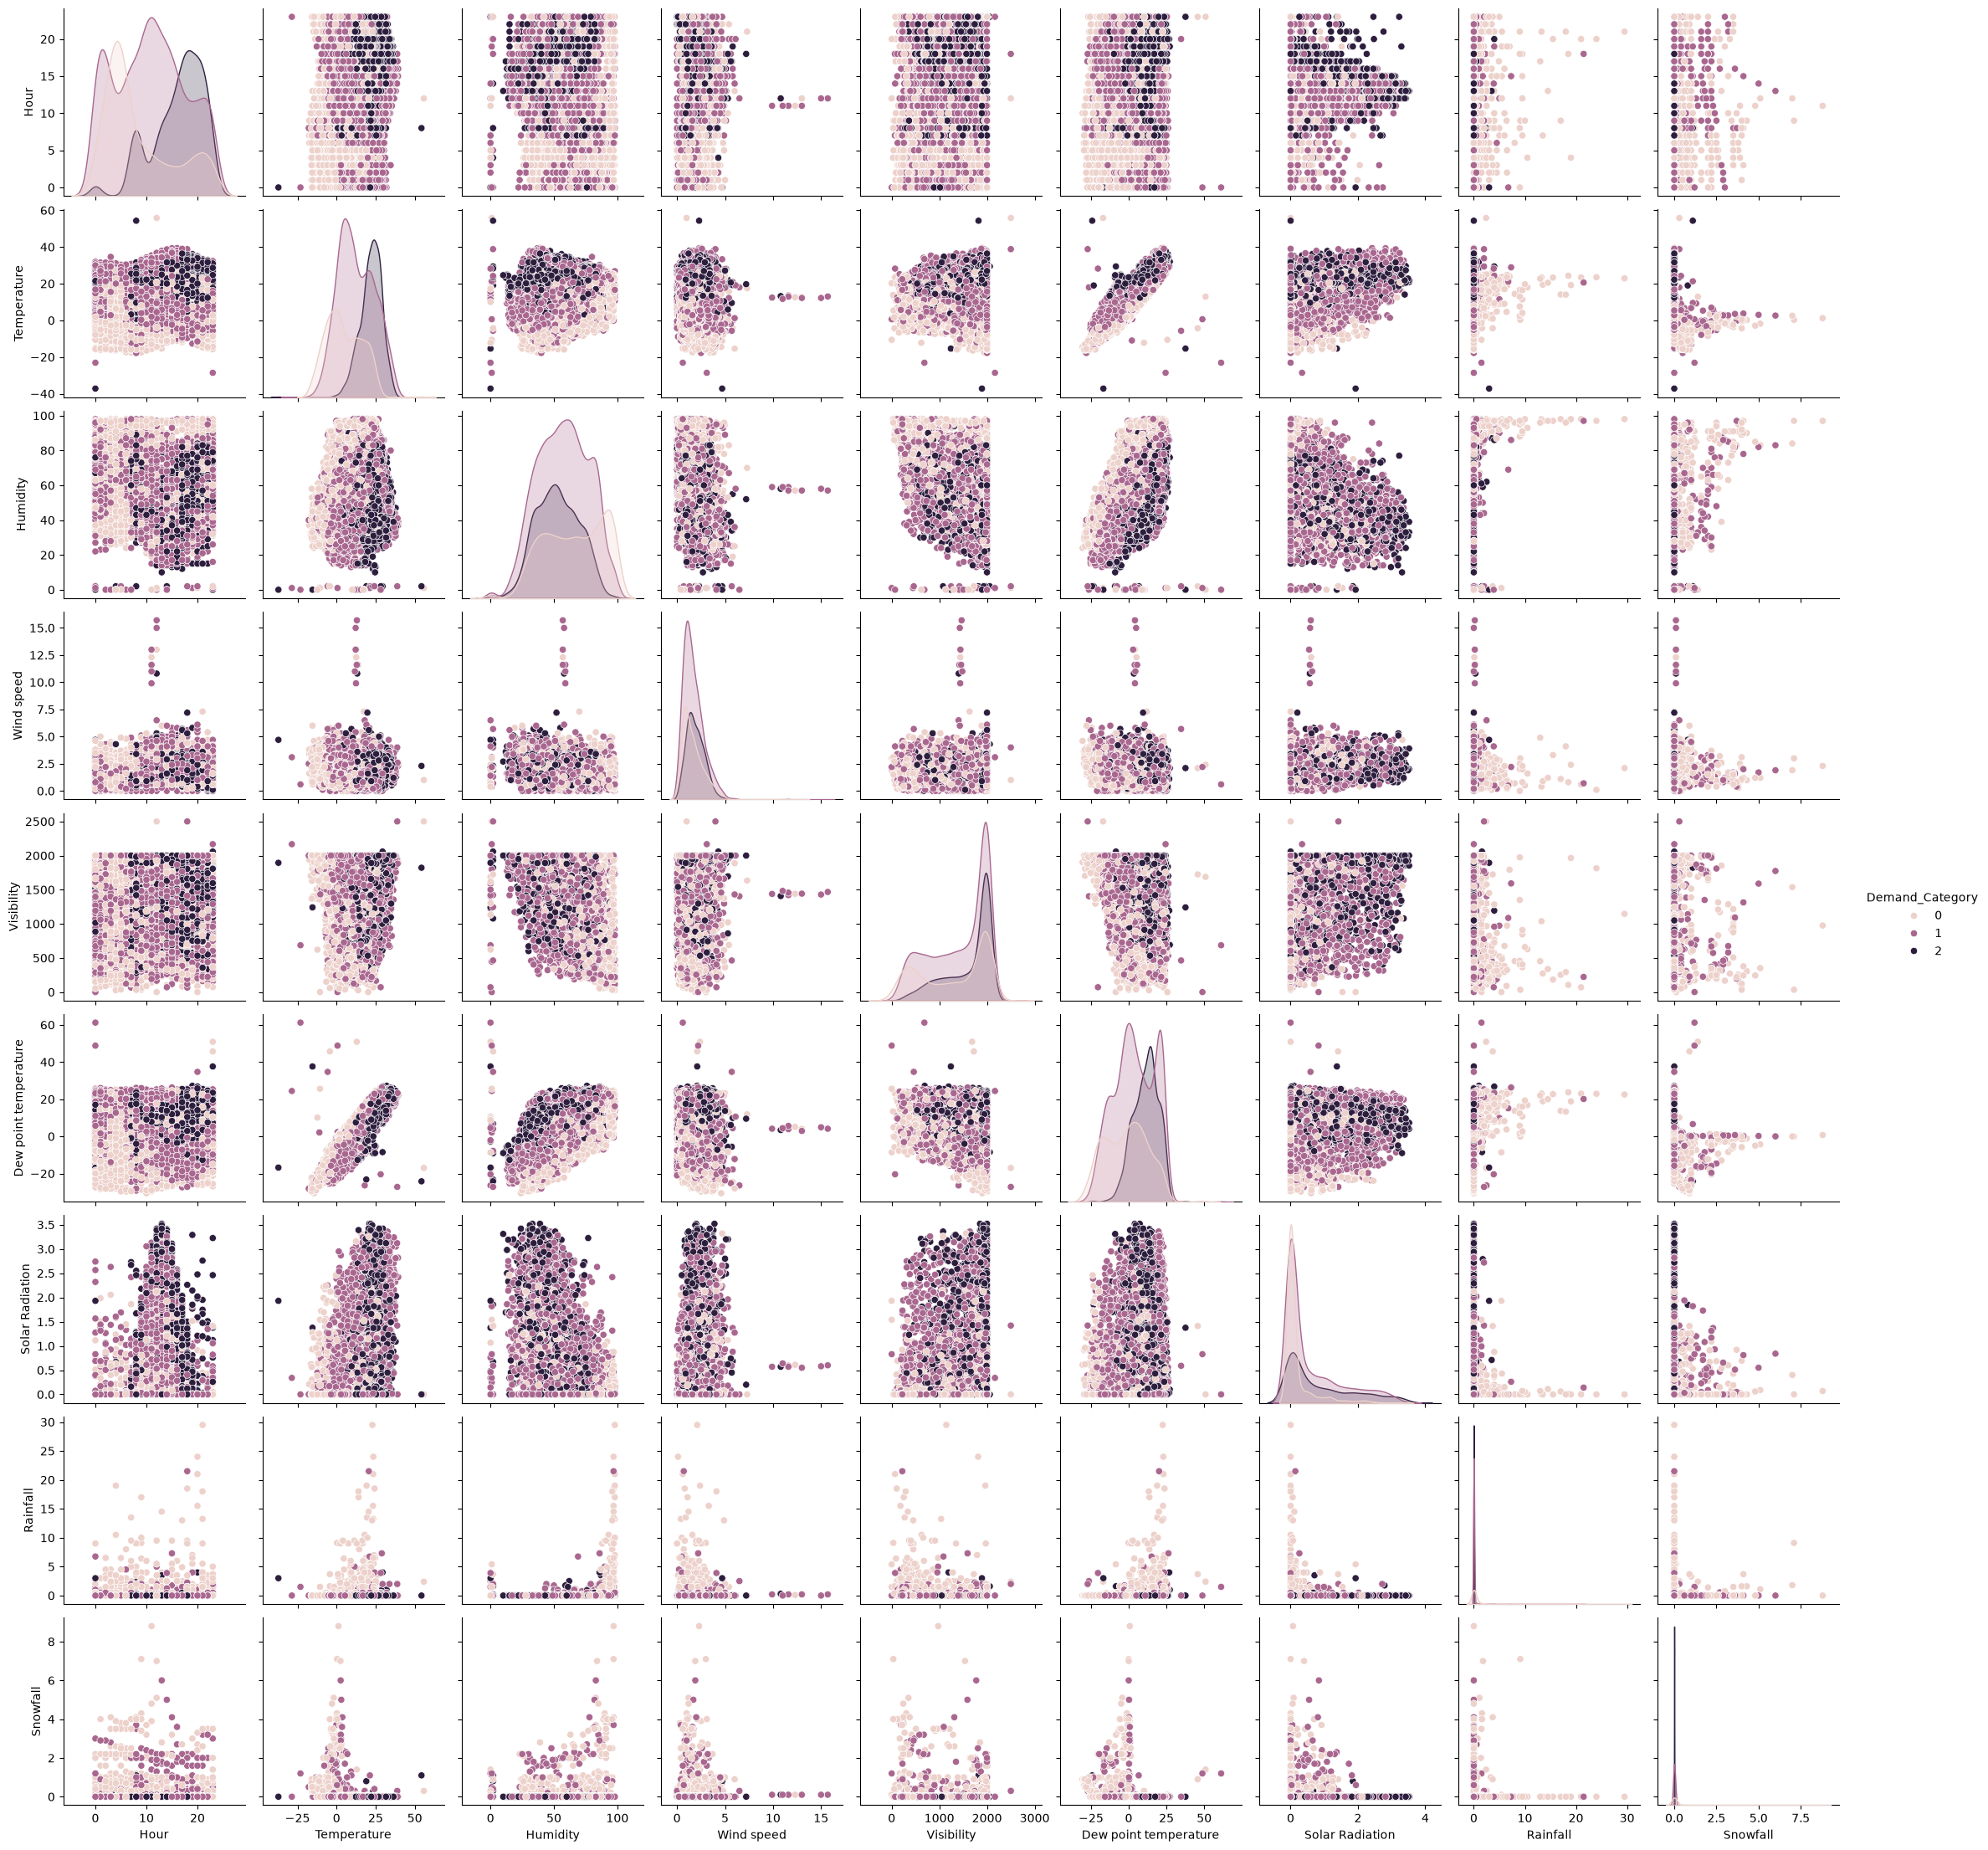

In [14]:
sns.pairplot(X, hue="Demand_Category")

0


c:\Users\glebo\Documents\University\Machine Learning\project\.venv\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\glebo\Documents\University\Machine Learning\project\.venv\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


<Axes: >

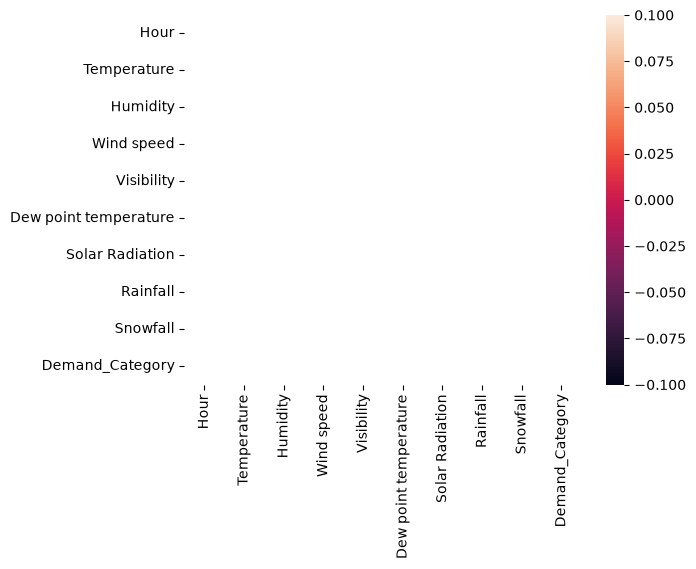

In [12]:
negwind = X[X["Hour"] < 0]
nonans = negwind.dropna()

correlation_df = nonans.drop(columns=nonans.select_dtypes(include=["object", "str"]).columns)
print(correlation_df.size)
sns.heatmap(correlation_df.corr(), annot=True)

In [7]:
print(negwind)

            Date  Hour  Temperature  Humidity  Wind speed  Visibility  \
96      4/3/2018     8         -9.7         0        -0.8         309   
2796  19/01/2018     9          8.3         1        -1.2         925   
4844    6/3/2018    20          8.6         2        -2.0           0   
4957    3/4/2018     0         47.3         0        -0.3           2   
5745    4/3/2018     8         -9.7         0        -0.8         309   
6195    3/4/2018     0         47.3         0        -0.3           2   

      Dew point temperature  Solar Radiation  Rainfall  Snowfall  Seasons  \
96                    -22.8             1.07       0.0       0.0   Wonter   
2796                  -29.9             2.22       0.7       1.4    Wintr   
4844                   32.7             0.56       1.7       0.7  Sproing   
4957                   10.5              NaN       0.0       0.3  Winteer   
5745                  -22.8             1.07       0.0       0.0   Wonter   
6195                   10.

In [8]:
X = filter_invalid(X, include_engineered_features=False)

In [9]:
print("Categoricals: ", X.select_dtypes(include=["object", "str"]).columns)


X.isna().sum()

Categoricals:  Index(['Date', 'Seasons', 'Holiday', 'Functioning Day'], dtype='str')


Date                       0
Hour                       0
Temperature              169
Humidity                   0
Wind speed                 0
Visibility                 0
Dew point temperature      0
Solar Radiation          563
Rainfall                 436
Snowfall                   0
Seasons                    0
Holiday                    0
Functioning Day            0
Demand_Category            0
dtype: int64

<Axes: >

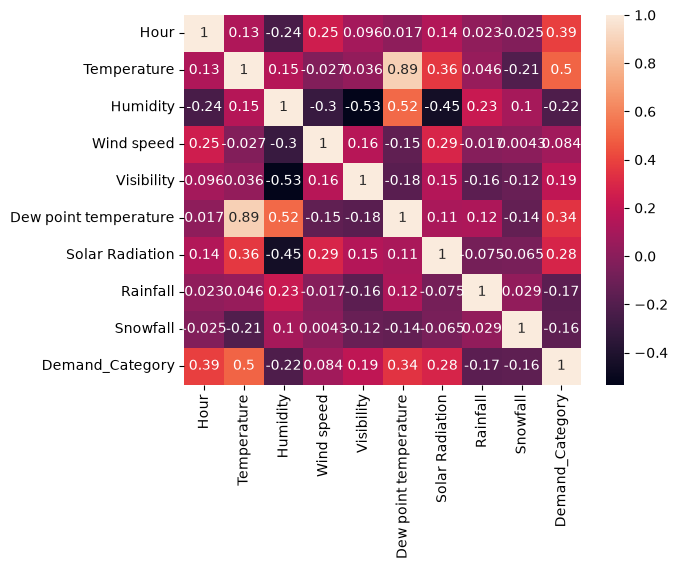

In [10]:
nonans = X.dropna()

correlation_df = X.drop(columns=nonans.select_dtypes(include=["object", "str"]).columns)
sns.heatmap(correlation_df.corr(), annot=True)

In [11]:
wi = WeatherImputer()
X = wi.fit_transform(X)
X.isna().sum()

Hour                     0
Temperature              0
Humidity                 0
Wind speed               0
Visibility               0
Dew point temperature    0
Solar Radiation          0
Rainfall                 0
Snowfall                 0
Seasons                  0
Holiday                  0
Functioning Day          0
Demand_Category          0
dtype: int64